# Лабораторна робота 2. Криптосистема AES

## Л2.1 Реалiзуйте криптосистеми AES-128, AES-192 i AES-256, включаючи раундовi функцiї та їх оберненi, алгоритми розподiлу ключiв, шифрування та дешифрування.

In [4]:
S_BOX = [
    0x63, 0x7c, 0x77, 0x7b, 0xf2, 0x6b, 0x6f, 0xc5, 0x30, 0x01, 0x67, 0x2b, 0xfe, 0xd7, 0xab, 0x76,
    0xca, 0x82, 0xc9, 0x7d, 0xfa, 0x59, 0x47, 0xf0, 0xad, 0xd4, 0xa2, 0xaf, 0x9c, 0xa4, 0x72, 0xc0,
    0xb7, 0xfd, 0x93, 0x26, 0x36, 0x3f, 0xf7, 0xcc, 0x34, 0xa5, 0xe5, 0xf1, 0x71, 0xd8, 0x31, 0x15,
    0x04, 0xc7, 0x23, 0xc3, 0x18, 0x96, 0x05, 0x9a, 0x07, 0x12, 0x80, 0xe2, 0xeb, 0x27, 0xb2, 0x75,
    0x09, 0x83, 0x2c, 0x1a, 0x1b, 0x6e, 0x5a, 0xa0, 0x52, 0x3b, 0xd6, 0xb3, 0x29, 0xe3, 0x2f, 0x84,
    0x53, 0xd1, 0x00, 0xed, 0x20, 0xfc, 0xb1, 0x5b, 0x6a, 0xcb, 0xbe, 0x39, 0x4a, 0x4c, 0x58, 0xcf,
    0xd0, 0xef, 0xaa, 0xfb, 0x43, 0x4d, 0x33, 0x85, 0x45, 0xf9, 0x02, 0x7f, 0x50, 0x3c, 0x9f, 0xa8,
    0x51, 0xa3, 0x40, 0x8f, 0x92, 0x9d, 0x38, 0xf5, 0xbc, 0xb6, 0xda, 0x21, 0x10, 0xff, 0xf3, 0xd2,
    0xcd, 0x0c, 0x13, 0xec, 0x5f, 0x97, 0x44, 0x17, 0xc4, 0xa7, 0x7e, 0x3d, 0x64, 0x5d, 0x19, 0x73,
    0x60, 0x81, 0x4f, 0xdc, 0x22, 0x2a, 0x90, 0x88, 0x46, 0xee, 0xb8, 0x14, 0xde, 0x5e, 0x0b, 0xdb,
    0xe0, 0x32, 0x3a, 0x0a, 0x49, 0x06, 0x24, 0x5c, 0xc2, 0xd3, 0xac, 0x62, 0x91, 0x95, 0xe4, 0x79,
    0xe7, 0xc8, 0x37, 0x6d, 0x8d, 0xd5, 0x4e, 0xa9, 0x6c, 0x56, 0xf4, 0xea, 0x65, 0x7a, 0xae, 0x08,
    0xba, 0x78, 0x25, 0x2e, 0x1c, 0xa6, 0xb4, 0xc6, 0xe8, 0xdd, 0x74, 0x1f, 0x4b, 0xbd, 0x8b, 0x8a,
    0x70, 0x3e, 0xb5, 0x66, 0x48, 0x03, 0xf6, 0x0e, 0x61, 0x35, 0x57, 0xb9, 0x86, 0xc1, 0x1d, 0x9e,
    0xe1, 0xf8, 0x98, 0x11, 0x69, 0xd9, 0x8e, 0x94, 0x9b, 0x1e, 0x87, 0xe9, 0xce, 0x55, 0x28, 0xdf,
    0x8c, 0xa1, 0x89, 0x0d, 0xbf, 0xe6, 0x42, 0x68, 0x41, 0x99, 0x2d, 0x0f, 0xb0, 0x54, 0xbb, 0x16
]

# Інверсний S-Box для дешифрування (Sec. 5.3.2)
INV_S_BOX = [0] * 256
for i in range(256):
    INV_S_BOX[S_BOX[i]] = i


# Раундові константи для Key Expansion (Sec. 5.2)
RCON = [0x00, 0x01, 0x02, 0x04, 0x08, 0x10, 0x20, 0x40, 0x80, 0x1B, 0x36]

Раунди в алгоритмі CIPHER() складаються з чотирьох основних перетворень над станом:

- **SubBytes** — до кожного байта застосовується таблиця підстановок (S-BOX).
- **ShiftRows** — рядки стану циклічно зсуваються на різну кількість позицій.
- **MixColumns** — виконується перемішування байтів у кожному стовпці.
- **AddRoundKey** — стан поєднується з раундовим ключем за допомогою XOR.

In [5]:
def bytes_to_state(b):
    """
    Перетворює 16 байтів у матрицю 4x4.
    В AES State (Стан) — це масив байтів, де дані заповнюються по колонках:
    s[r,c]=in[r+4c], де r — рядок, а c — стовпець (розділ 3.4).
    """
    state = [[0]*4 for _ in range(4)]
    for i in range(16):
        state[i % 4][i // 4] = b[i]
        # i % 4 — це залишок від ділення, що відповідає індексу рядка r
        # i // 4 — це цілочисельне ділення, що відповідає індексу стовпця c
    return state


def state_to_bytes(state):
    """
    Перетворює матрицю Стан назад у послідовність байтів.
    """
    res = []
    for c in range(4):
        for r in range(4):
            res.append(state[r][c])
    return bytes(res)


# GF(2^8) 
def xtime(a):
    """
    Множення на {02} (поліном x) у скінченному полі GF(2^8). 
    Eq. 4.11 у FIPS-197. 
    Логіка операторів:
    - a << 1: Побітовий зсув вліво (множення на 2).
    - a & 0x80: Побітове 'I' (AND) з 10000000. Перевіряє, чи був 8-й біт = 1.
    - ^= 0x1b: Побітовий XOR (додавання в GF(2)). 0x1b — це поліном додавання
               x^4 + x^3 + x + 1.
    - & 0xff: Маска, що тримає результат у межах 8 бітів (1 байта).
    """
    res = a << 1
    if a & 0x80:      # Якщо 8-й біт встановлено, виникає переповнення за x^8
        res ^= 0x1b   # Додаємо (XOR) за незвідним многочленом m(x)
    return res & 0xff # Повертаємо 1 байт


def mul(a, b):
    """
    Множення двох елементів у GF(2^8) за допомогою алгоритму xtime.
    Використовується для MixColumns та InvMixColumns.
    """
    res = 0
    for _ in range(8):
        if b & 1:     # Якщо поточний біт множника = 1
            res ^= a  # Додаємо (XOR) поточне зміщене значення до результату
        a = xtime(a)  # Наступна степінь x
        b >>= 1       # Зсув множника вправо
    return res


# ============================================================
# РАУНДОВІ ТРАНСФОРМАЦІЇ
# ============================================================

def sub_bytes(state):
    """
    SubBytes: Нелінійна заміна кожного байта за допомогою S-Box (Sec. 5.1.1).
    state[r,c] = S_BOX[state[r,c]].
    """
    for r in range(4):
        for c in range(4):
            state[r][c] = S_BOX[state[r][c]]
    return state


def inv_sub_bytes(state):
    """ Обернена SubBytes (Sec. 5.3.2). Використовує INV_S_BOX. """
    for r in range(4):
        for c in range(4):
            state[r][c] = INV_S_BOX[state[r][c]]
    return state


def shift_rows(state):
    """
    ShiftRows: Циклічний зсув вліво останніх трьох рядків Стану (Sec. 5.1.2).
    - Рядок 0: без зсуву.
    - Рядок 1: на 1 байт.
    - Рядок 2: на 2 байти.
    - Рядок 3: на 3 байти.
    """
    state[1] = state[1][1:] + state[1][:1]
    state[2] = state[2][2:] + state[2][:2]
    state[3] = state[3][3:] + state[3][:3]
    return state


def inv_shift_rows(state):
    """ Обернений ShiftRows (Sec. 5.3.1): Циклічний зсув вправо. """
    state[1] = state[1][-1:] + state[1][:-1]
    state[2] = state[2][-2:] + state[2][:-2]
    state[3] = state[3][-3:] + state[3][:-3]
    return state


def mix_columns(state):
    """
    MixColumns: Множення кожної колонки Стану на фіксований многочлен a(x) (Sec. 5.1.3).
    Це лінійна трансформація в GF(2^8).
    Використовуються коефіцієнти {02, 03, 01, 01}. 
    """
    for c in range(4):
        s = [state[r][c] for r in range(4)]
        # XOR (^) тут — це додавання в полі GF(2^8).
        state[0][c] = mul(s[0], 2) ^ mul(s[1], 3) ^ s[2] ^ s[3]
        state[1][c] = s[0] ^ mul(s[1], 2) ^ mul(s[2], 3) ^ s[3]
        state[2][c] = s[0] ^ s[1] ^ mul(s[2], 2) ^ mul(s[3], 3)
        state[3][c] = mul(s[0], 3) ^ s[1] ^ s[2] ^ mul(s[3], 2)
    return state


def inv_mix_columns(state):
    """ Обернений MixColumns (Sec. 5.3.3). Коефіцієнти: {0e, 0b, 0d, 09}."""
    for c in range(4):
        s = [state[r][c] for r in range(4)]
        state[0][c] = mul(s[0], 14) ^ mul(s[1], 11) ^ mul(s[2], 13) ^ mul(s[3], 9)
        state[1][c] = mul(s[0], 9) ^ mul(s[1], 14) ^ mul(s[2], 11) ^ mul(s[3], 13)
        state[2][c] = mul(s[0], 13) ^ mul(s[1], 9) ^ mul(s[2], 14) ^ mul(s[3], 11)
        state[3][c] = mul(s[0], 11) ^ mul(s[1], 13) ^ mul(s[2], 9) ^ mul(s[3], 14)
    return state


def add_round_key(state, round_key):
    """
    AddRoundKey: Побітовий XOR кожного байта Стану з раундовим ключем (Sec. 5.1.4).
    Це єдина частина, де використовується секретний ключ. 
    """
    for c in range(4):
        for r in range(4):
            state[r][c] ^= round_key[c][r] # round_key[c] — це слово (word) ключа
    return state


# ============================================================
# KEY EXPANSION (Sec. 5.2)
# ============================================================

def rot_word(word):
    """ RotWord: Циклічний зсув байтів у слові [a0, a1, a2, a3] -> [a1, a2, a3, a0]."""
    return word[1:] + word[:1]


def sub_word(word):
    """ SubWord: Заміна байтів у слові за допомогою S-Box."""
    return [S_BOX[b] for b in word]


def key_expansion(key):
    """
    KeyExpansion: Створює розклад ключів (Key Schedule) (Sec. 5.2).
    - Nk: кількість слів у початковому ключі (4 для AES-128).
    - Nr: кількість раундів (10 для AES-128). 
    """
    Nk = len(key) // 4
    Nr = Nk + 6

    w = []
    # Копіюємо початковий ключ у перші Nk слів
    for i in range(Nk):
        w.append(list(key[4*i:4*(i+1)]))

    # Генеруємо наступні слова (до 4*(Nr+1))
    for i in range(Nk, 4*(Nr+1)):
        temp = w[i-1].copy()

        if i % Nk == 0:
            # Спеціальна трансформація: RotWord -> SubWord -> XOR з Rcon
            temp = sub_word(rot_word(temp))
            temp[0] ^= RCON[i // Nk]
        elif Nk > 6 and i % Nk == 4:
            # Додаткова SubWord для AES-256 (Nk=8)
            temp = sub_word(temp)

        # Нове слово = XOR слова Nk кроків назад з обробленим попереднім словом
        w.append([a ^ b for a, b in zip(w[i-Nk], temp)])

    return w, Nr


def get_round_key(w, round_idx):
    """ Вибирає 4 слова (16 байтів) для конкретного раунду. """
    return [w[round_idx*4 + i] for i in range(4)]


# ============================================================
# ENCRYPTION & DECRYPTION (Algorithm 1 & 3)
# ============================================================

def cipher(input_bytes, w, Nr):
    """
    Algorithm 1: Процедура шифрування. 
    Включає початкове накладання ключа, Nr-1 повних раундів та фінальний раунд.
    """
    state = bytes_to_state(input_bytes)

    # Початковий раунд: AddRoundKey(State, Key0)
    state = add_round_key(state, get_round_key(w, 0))

    # Раунди від 1 до Nr-1
    for r in range(1, Nr):
        state = sub_bytes(state)
        state = shift_rows(state)
        state = mix_columns(state) 
        state = add_round_key(state, get_round_key(w, r))

    # Фінальний раунд (Nr): MixColumns пропускається.
    state = sub_bytes(state)
    state = shift_rows(state)
    state = add_round_key(state, get_round_key(w, Nr))

    return state_to_bytes(state)


def inv_cipher(input_bytes, w, Nr):
    """ Algorithm 3: Процедура дешифрування. Процеси йдуть у зворотному порядку."""
    state = bytes_to_state(input_bytes)

    # Починаємо з останнього ключа
    state = add_round_key(state, get_round_key(w, Nr))

    # Обернені раунди (Nr-1 до 1)
    for r in range(Nr-1, 0, -1):
        state = inv_shift_rows(state)
        state = inv_sub_bytes(state)
        state = add_round_key(state, get_round_key(w, r))
        state = inv_mix_columns(state)

    # Фінальний крок
    state = inv_shift_rows(state)
    state = inv_sub_bytes(state)
    state = add_round_key(state, get_round_key(w, 0))

    return state_to_bytes(state)


def test_aes(key):
    w, Nr = key_expansion(key)
    plaintext = b"HelloAES12345678" # 16 байтів

    ct = cipher(plaintext, w, Nr)
    pt = inv_cipher(ct, w, Nr)

    print("Key length:", len(key))
    print(f"Bits: {len(key)*8} bits")
    print(f"Nr (Rounds): {Nr}")
    print(f"Ciphertext (hex): {ct.hex()}")
    print(f"Decryption correct: {pt == plaintext}")
    print("-" * 40)


test_aes(b"0123456789abcdef")                     # AES-128 (Nk=4, Nr=10)
test_aes(b"0123456789abcdef01234567")             # AES-192 (Nk=6, Nr=12)
test_aes(b"0123456789abcdef0123456789abcdef")     # AES-256 (Nk=8, Nr=14)

Key length: 16
Bits: 128 bits
Nr (Rounds): 10
Ciphertext (hex): e5970944489cfb6f5287d1849f433fed
Decryption correct: True
----------------------------------------
Key length: 24
Bits: 192 bits
Nr (Rounds): 12
Ciphertext (hex): 801ed308425e30e86b20eb5b115994a9
Decryption correct: True
----------------------------------------
Key length: 32
Bits: 256 bits
Nr (Rounds): 14
Ciphertext (hex): e0014f4cdc56ff93fd36d6e6344e70b2
Decryption correct: True
----------------------------------------


## Л 2.2  Для кожної з криптосистем AES-128, AES-192 і AES-256 визначити, скільки в середньому (за 100000 випадкових випробувань) бітів криптотексту змінюється при зміні:
- а) одного біта відкритого тексту;
- б) одного біта ключа.

In [6]:
import random

def count_diff_bits(b1, b2):
    """
    Рахує кількість відмінних бітів за допомогою  XOR.
    Використовує вбудований метод bit_count().
    """
    # Об'єднуємо 16 байтів у одне велике ціле число для операції XOR
    n1 = int.from_bytes(b1, byteorder='big')
    n2 = int.from_bytes(b2, byteorder='big')
    # Операція ^ (XOR) дасть '1' тільки там, де біти відрізняються
    return (n1 ^ n2).bit_count()

def flip_random_bit(data):
    """
    Змінює рівно один випадковий біт у байтовій послідовності.
    """
    data_list = list(data)
    byte_idx = random.randint(0, len(data_list) - 1) # Вибираємо випадковий байт
    bit_idx = random.randint(0, 7)                   # Вибираємо випадковий біт (0-7)
    
    # Оператор ^ (XOR) з маскою (1 << bit_idx) інвертує обраний біт
    data_list[byte_idx] ^= (1 << bit_idx)
    return bytes(data_list)

def run_avalanche_test_text(iterations=100000):
    # Специфікації для різних типів AES згідно з FIPS 197 
    aes_types = [
        {"name": "AES-128", "key_size": 16},
        {"name": "AES-192", "key_size": 24},
        {"name": "AES-256", "key_size": 32}
    ]

    print(f"Запуск тесту: зміна 1 біта ТЕКСТА ({iterations} ітерацій)\n")

    for aes in aes_types:
        total_diff_bits = 0
        
        # Випадковий ключ для поточної серії випробувань
        key = random.randbytes(aes["key_size"])
        # Розширюємо ключ один раз для швидкості
        w, nr = key_expansion(key)

        for _ in range(iterations):
            # 1. Генеруємо випадковий текст
            plaintext = random.randbytes(16)
            
            # 2. Зашифровуємо оригінал (C1) 
            c1 = cipher(plaintext, w, nr)
            
            # 3. Змінюємо 1 випадковий біт у тексті
            modified_plaintext = flip_random_bit(plaintext)
            
            # 4. Зашифровуємо змінений текст (C2)
            c2 = cipher(modified_plaintext, w, nr)
            
            # 5. Рахуємо різницю бітів
            total_diff_bits += count_diff_bits(c1, c2)

        # 6. Знаходимо середнє значення
        average = total_diff_bits / iterations
        print(f"Результати для {aes['name']}:")
        print(f"  - Середня кількість змінених бітів: {average:.4f}")

# Запуск тесту
if __name__ == "__main__":
    # Для демонстрації можна почати з 10 000 ітерацій, щоб код відпрацював швидше
    run_avalanche_test_text(iterations=10000)

Запуск тесту: зміна 1 біта ТЕКСТА (10000 ітерацій)

Результати для AES-128:
  - Середня кількість змінених бітів: 64.0739
Результати для AES-192:
  - Середня кількість змінених бітів: 64.0232
Результати для AES-256:
  - Середня кількість змінених бітів: 64.0192


In [7]:
def run_avalanche_test_key(iterations=100000):
    aes_types = [
        {"name": "AES-128", "key_size": 16}, # Nk=4, Nr=10
        {"name": "AES-192", "key_size": 24}, # Nk=6, Nr=12
        {"name": "AES-256", "key_size": 32}  # Nk=8, Nr=14
    ]

    print(f"Запуск тесту: зміна 1 біта КЛЮЧА ({iterations} ітерацій)\n")

    for aes in aes_types:
        total_diff_bits = 0
        
        for _ in range(iterations):
            # 1. Генеруємо випадковий текст та випадковий ключ
            plaintext = random.randbytes(16)
            original_key = random.randbytes(aes["key_size"])
            
            # 2. Шифруємо текст оригінальним ключем (C1)
            # Спочатку розширюємо оригінальний ключ
            w1, nr = key_expansion(original_key)
            c1 = cipher(plaintext, w1, nr)
            
            # 3. Змінюємо рівно 1 випадковий біт у КЛЮЧІ
            modified_key = flip_random_bit(original_key)
            
            # 4. Шифруємо ТОЙ САМИЙ текст новим ключем (C2)
            # Потрібно заново виконати KeyExpansion для зміненого ключа
            w2, _ = key_expansion(modified_key)
            c2 = cipher(plaintext, w2, nr)
            
            # 5. Рахуємо кількість відмінних бітів між C1 та C2
            total_diff_bits += count_diff_bits(c1, c2)

        # 6. Обчислюємо середнє значення
        average = total_diff_bits / iterations
        print(f"Результати для {aes['name']}:")
        print(f"  - Середня зміна бітів: {average:.4f}")

if __name__ == "__main__":
    run_avalanche_test_key(iterations=100000)

Запуск тесту: зміна 1 біта КЛЮЧА (100000 ітерацій)

Результати для AES-128:
  - Середня зміна бітів: 63.9894
Результати для AES-192:
  - Середня зміна бітів: 63.9996
Результати для AES-256:
  - Середня зміна бітів: 64.0480


## Л 2.3  Як змiнюються цi кiлькостi при змiнi (як зменшеннi, так i збiльшеннi) кiлькостi раундiв для AES-128?

###  Теоретичне обґрунтування
Згідно зі стандартом **NIST FIPS 197**, для алгоритму AES-128 встановлено **10 раундів**. Кожен раунд складається з трансформацій `SubBytes`, `ShiftRows`, `MixColumns` та `AddRoundKey`. Саме багаторазове повторення цих кроків забезпечує стан, коли кожен біт входу впливає на кожен біт виходу.

### 1. Зменшення кількості раундів (наприклад, до 1–4)
* **Результат**: Кількість змінених бітів буде значно меншою за середній показник у 64 біти (50% блоку).
* **Пояснення**: При малій кількості раундів дані не встигають повністю змішатися. Зміна одного біта на вході зачепить лише обмежену частину вихідного результату, оскільки операції `SubBytes`, `ShiftRows` та `MixColumns` не встигнуть поширити зміну на всю матрицю стану (State).

### 2. Стандартна кількість раундів (10 раундів)
* **Результат**: Кількість змінених бітів стабілізується в середньому на рівні **64 бітів**.
* **Пояснення**: Це оптимальна кількість, визначена NIST для забезпечення повної незалежності кожного біта результату від кожного біта входу. Після 10 раундів кожен байт матриці State вже багаторазово пройшов через етапи заміни та перемішування.

### 3. Збільшення кількості раундів (наприклад, понад 14)
* **Результат**: Кількість змінених бітів **залишиться на рівні 64**.
* **Пояснення**: Коли досягнуто стану, де змінюється 50% бітів (максимальна хаотичність), подальші повторення операцій не можуть зробити результат "ще більш випадковим". 
* **Висновок**: Додавання зайвих раундів не покращує показники зміни бітів, але суттєво уповільнює роботу алгоритму та витрачає більше ресурсів.


Обчислення для 14 раундів...
Раунд 1: середня зміна 4.11 бітів
Раунд 2: середня зміна 16.10 бітів
Раунд 3: середня зміна 63.96 бітів
Раунд 4: середня зміна 64.12 бітів
Раунд 5: середня зміна 63.91 бітів
Раунд 6: середня зміна 64.26 бітів
Раунд 7: середня зміна 64.28 бітів
Раунд 8: середня зміна 63.83 бітів
Раунд 9: середня зміна 64.32 бітів
Раунд 10: середня зміна 64.03 бітів
Раунд 11: середня зміна 63.82 бітів
Раунд 12: середня зміна 64.09 бітів
Раунд 13: середня зміна 64.17 бітів
Раунд 14: середня зміна 63.99 бітів


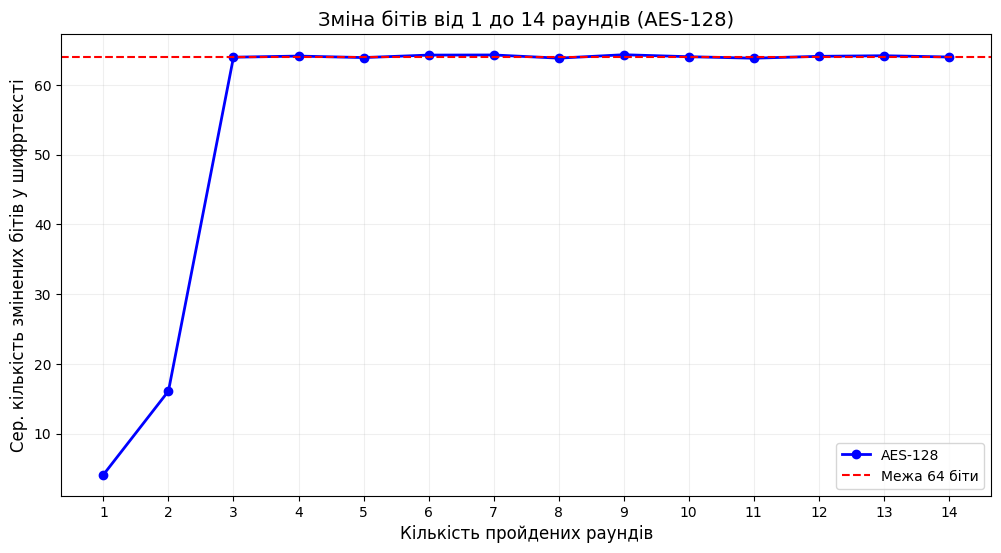

In [35]:
import matplotlib.pyplot as plt
import random

RCON_EXTENDED = [0x00, 0x01, 0x02, 0x04, 0x08, 0x10, 0x20, 0x40, 0x80, 0x1B, 0x36, 0x6C, 0xD8, 0xAB, 0x4D]


def key_expansion_forced_14(key):
    """
    Генерація розкладу ключів (Key Schedule) для 14 раундів.
    Мета: Розтягнути один вхідний ключ на 15 унікальних раундових ключів.
    """
    # Nk — кількість 32-бітних слів у вхідному ключі. Для AES-128: 16 байтів / 4 = 4 слова.
    Nk = len(key) // 4  
    Nr = 14             
    
    # Сюди будемо записувати всі згенеровані слова (всього має бути 60 слів).
    w = []
    
    # Перші 4 слова — це просто ваш вхідний пароль, розбитий по 4 байти.
    # Це буде "нульовий" ключ для початкового етапу (AddRoundKey перед 1-м раундом).
    for i in range(Nk):
        w.append(list(key[4*i:4*(i+1)]))

    # Генерація решти 56 слів (від індексу 4 до 59).
    for i in range(Nk, 4 * (Nr + 1)):
        # Беремо попереднє слово (w[i-1]) як основу для створення нового.
        temp = w[i-1].copy() 
        
        # для кожного четвертого слова, для того, щоб ключі не були схожими і мали складну структуру.
        if i % Nk == 0:
            # 1. RotWord: циклічний зсув байтів у слові [a,b,c,d] -> [b,c,d,a].
            # 2. SubWord: заміна кожного байта через таблицю S-Box (нелінійність).
            temp = sub_word(rot_word(temp))
            
            # 3. Додавання раундової константи (RCON).
            # Ми робимо XOR першого байта слова з числом з масиву RCON.
            rcon_idx = i // Nk
            if rcon_idx < len(RCON_EXTENDED):
                temp[0] ^= RCON_EXTENDED[rcon_idx]
        

        # Нове слово створюється як результат XOR:
        # (слово, що було 4 позиції назад) XOR (оброблене слово temp).
        w.append([a ^ b for a, b in zip(w[i-Nk], temp)])
        
    return w, Nr

def run_aes128_14_rounds_test(iterations=1000):
    """
    Функція збирає статистику зміни бітів для кожного раунду від 1 до 14.
    """
    key_128 = b"0123456789abcdef"
    
    # Отримуємо розклад ключів, розрахований на 14 раундів
    w_forced, nr_forced = key_expansion_forced_14(key_128)
    
    rounds_range = range(1, 15) # Список раундів для тестування
    results = [] # Середні результати для графіка

    print(f"Обчислення для {nr_forced} раундів...")
    
    for r in rounds_range:
        total_diff_bits = 0
        for _ in range(iterations):
            # 1. Генеруємо випадковий текст (16 байтів)
            plaintext = random.randbytes(16)
            
            # 2. Зашифровуємо його рівно на r раундів
            c1 = cipher_flexible(plaintext, w_forced, r)
            
            # 3. Змінюємо 1 випадковий біт у вхідному тексті
            modified_plaintext = flip_random_bit(plaintext)
            
            # 4. Зашифровуємо змінений текст тим самим ключем на ті ж r раундів
            c2 = cipher_flexible(modified_plaintext, w_forced, r)
            
            # 5. Рахуємо кількість відмінних бітів
            total_diff_bits += count_diff_bits(c1, c2)
        
        # Обчислюємо середнє арифметичне для поточної кількості раундів
        avg = total_diff_bits / iterations
        results.append(avg)
        print(f"Раунд {r}: середня зміна {avg:.2f} бітів")    
    return list(rounds_range), results

rounds, bit_changes = run_aes128_14_rounds_test(iterations=1000)
plt.figure(figsize=(12, 6))
plt.plot(rounds, bit_changes, marker='o', color='blue', linewidth=2, label='AES-128')
plt.axhline(y=64, color='red', linestyle='--', label='Межа 64 біти')

plt.title('Зміна бітів від 1 до 14 раундів (AES-128)', fontsize=14)
plt.xlabel('Кількість пройдених раундів', fontsize=12)
plt.ylabel('Сер. кількість змінених бітів у шифртексті', fontsize=12)
plt.xticks(rounds) 
plt.grid(True, alpha=0.2)
plt.legend() 
plt.show()

In [34]:
3 << 1

6